# Generate Plots of Absolute Geostrophic Velocity in transects of the Beaufort Gyre

### Configure the notebook and load necessary packages

In [168]:
#Jupyter Notebook config
%load_ext autoreload
%autoreload 2
%matplotlib widget

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [169]:
from functools import reduce

#Load necessary python packages
import matplotlib.pyplot as plt
from matplotlib import colormaps
import seaborn as sns
import cartopy.crs as ccrs
from cmocean import cm
import numpy as np
import xarray as xr
import gsw
from scipy.spatial import cKDTree
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components

from ipywidgets import widgets
from IPython.display import display

#Import custom package for working with Beaufort Gyre data
from datatools import io
import datatools.ctd.operations as dsops
import datatools.plots.maps as mapper
import datatools.plots.section as plotter
import ocean_tools as fod
from datatools.DOT.DataServer import DataServer

In [170]:
#Define if processing should be done from scratch or preload CTD transects
process_from_scratch = True

### Extract the CTD Transects from the full dataset
* Read in the data
* Extract each transect
* Plot the transects on a map

In [171]:
#Read raw CTD data
ds = io.readers.readLSSL("/Users/ben/Desktop/3D-TEA-BAG/data/BGOS_shipboard_03_25.nc")

if process_from_scratch:
    #Slice the data to extract each transect
    #Eastern N-S transect (IVO 140˚W)
    e_ns_transect = dsops.var_slice(ds, 'lon', -140.5, -139.5)

    #Westren N-S transect (IVO 150˚W)
    w_ns_transect = dsops.var_slice(ds, 'lon', w_ns_main_slice_start := -150.75, -149.25)
    #Also capture small "dogleg" at the southren end of the transect
    w_ns_dogleg = dsops.var_slice(ds, 'lat', 70,72) #Latitude slice
    w_ns_dogleg = dsops.var_slice(w_ns_dogleg, 'lon', -153, w_ns_main_slice_start) #Longitude Slice
    #Combine datasets
    w_ns_transect = reduce(lambda a, b: a.combine_first(b), [w_ns_transect, w_ns_dogleg])

    #Northren E-W transect (IVO 75˚-78˚N)
    n_ew_transect = dsops.var_slice_line(ds,
                                        lat1 = 78.1,
                                        lon1 = -154.4,
                                        lat2 = 75.5,
                                        lon2 = -128.7,
                                        tolerance=25)
    #Get clump of stations at the northren end of the transect
    n_ew_n_clump = dsops.var_slice(ds, 'lat', 78.2,78.4) #Latitude slice
    n_ew_n_clump = dsops.var_slice(n_ew_n_clump, 'lon', -155, -152) #Longitude Slice

    #Get dogleg at the southren end of the transect
    n_ew_s_dogleg = dsops.var_slice(ds, 'lat', 75.7,75.9) #Latitude slice
    n_ew_s_dogleg = dsops.var_slice(n_ew_s_dogleg, 'lon', -129, -127) #Longitude Slice

    #Combine datasets
    n_ew_transect = reduce(lambda a, b: a.combine_first(b), [n_ew_transect, n_ew_n_clump, n_ew_s_dogleg])

    #Southren E-W transect (IVO 71˚-76˚N)
    #Northren leg from 160˚W to 150˚W
    s_ew_n_leg = dsops.var_slice_line(ds,
                                    lat1 = 76,
                                    lon1 = -160,
                                    lat2 = 75,
                                    lon2 = -150,
                                    tolerance= 35)

    #Cut off random points caught up by the extention of the line past the 150˚-160˚W, 75-76˚N box
    s_ew_n_leg = dsops.var_slice(s_ew_n_leg, 'lat', 75,76) #Latitude slice
    s_ew_n_leg = dsops.var_slice(s_ew_n_leg, 'lon', -160, -150) #Longitude Slice


    #Middle leg from 150˚W to 140˚W
    s_ew_m_leg = dsops.var_slice_line(ds,
                                    lat1 = 75,
                                    lon1 = -150,
                                    lat2 = 74,
                                    lon2 = -140,
                                    tolerance= 35)
    #Cut off random points caught up by the extention of the line past the 140˚-150˚W, 74-75˚N box
    s_ew_m_leg = dsops.var_slice(s_ew_m_leg, 'lat', 74,75) #Latitude slice
    s_ew_m_leg = dsops.var_slice(s_ew_m_leg, 'lon', -150, -140) #Longitude Slice

    #Southren leg from 140˚W to 129˚W
    s_ew_s_leg = dsops.var_slice_line(ds,
                                    lat1 = 74,
                                    lon1 = -140,
                                    lat2 = 71,
                                    lon2 = -129,
                                    tolerance=40)
    #Cut off random points caught up by the extention of the line past the 129˚-140˚W, 71-74˚N box
    s_ew_s_leg = dsops.var_slice(s_ew_s_leg, 'lat', 71,74) #Latitude slice
    s_ew_s_leg = dsops.var_slice(s_ew_s_leg, 'lon', -140, -129) #Longitude Slice

    #Grab a few stragglers at the northren terminus
    s_ew_n_clump = dsops.var_slice(ds, 'lat', 75.9, 76.1) #Latitude slice
    s_ew_n_clump = dsops.var_slice(s_ew_n_clump, 'lon', -161, -159) #Longitude Slice

    #Grab a few stragglers IVO 150˚W 75N
    s_ew_m_clump = dsops.var_slice(ds, 'lat', 74.8, 75.2) #Latitude slice
    s_ew_m_clump = dsops.var_slice(s_ew_m_clump, 'lon', -150.2, -149.8) #Longitude Slice

    #Grab a few stragglers IVO 140˚W 74N
    s_ew_s_clump = dsops.var_slice(ds, 'lat', 73.8, 74.2) #Latitude slice
    s_ew_s_clump = dsops.var_slice(s_ew_s_clump, 'lon', -140.2, -139.8) #Longitude Slice

    #Combine datasets
    s_ew_transect = reduce(lambda a, b: a.combine_first(b), [s_ew_n_leg, s_ew_m_leg, s_ew_s_leg, s_ew_n_clump, s_ew_m_clump, s_ew_s_clump])



    e_ns_transect = e_ns_transect.assign_attrs(direction = 'ns')
    w_ns_transect = w_ns_transect.assign_attrs(direction = 'ns')
    n_ew_transect = n_ew_transect.assign_attrs(direction = 'ew')
    s_ew_transect = s_ew_transect.assign_attrs(direction = 'ew')

In [172]:
if not process_from_scratch:
    #Or load from a pre-processed datafile
    path = "/Users/ben/Desktop/3D-TEA-BAG/data/processed"
    e_ns_transect = xr.load_dataset(f"{path}/e_ns_transect.nc")
    w_ns_transect = xr.load_dataset(f"{path}/w_ns_transect.nc")
    n_ew_transect = xr.load_dataset(f"{path}/n_ew_transect.nc")
    s_ew_transect = xr.load_dataset(f"{path}/s_ew_transect.nc")

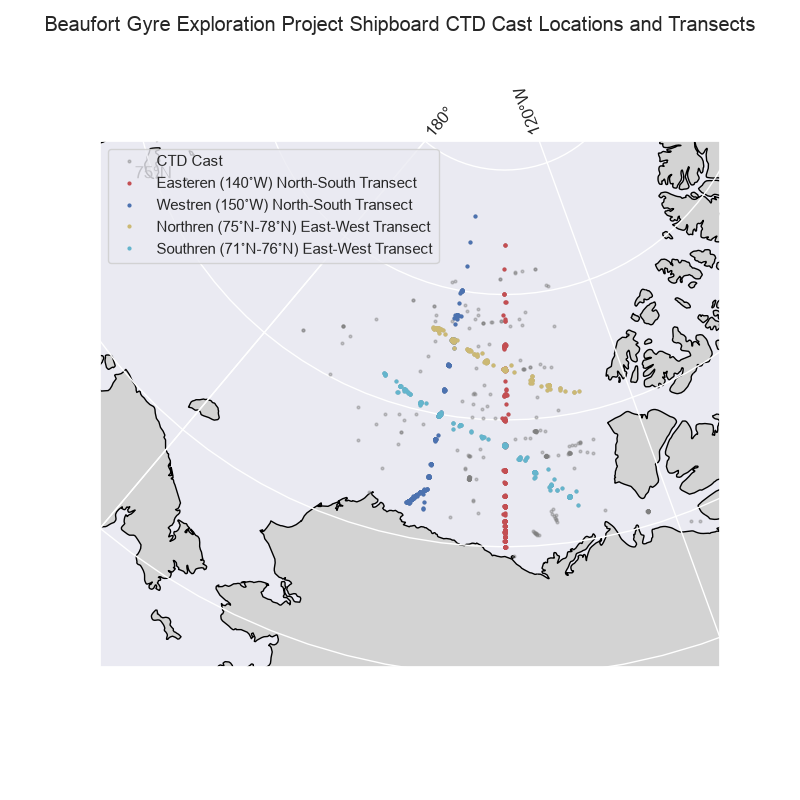

In [173]:
#Plot the transects

#Setup the basemap
transect_location_figure = plt.figure(figsize=(8,8))
projection=ccrs.NorthPolarStereo(central_longitude=-140)
extent = [-180, -120, 65, 85]

ax = mapper.setup_map(figure=transect_location_figure,
                 projection=projection,
                 extent=extent)

#Plot all casts
ax = mapper.plot_station_locations(ax = ax, ds = ds, alpha=0.4, color='gray', label = 'CTD Cast')

#Plat the transects
ax = mapper.plot_station_locations(ax = ax, ds = e_ns_transect, color='r', label = 'Easteren (140˚W) North-South Transect')
ax = mapper.plot_station_locations(ax = ax, ds = w_ns_transect, color='b', label = 'Westren (150˚W) North-South Transect')
ax = mapper.plot_station_locations(ax = ax, ds = n_ew_transect, color='y', label = 'Northren (75˚N-78˚N) East-West Transect')
ax = mapper.plot_station_locations(ax = ax, ds = s_ew_transect, color='c', label = 'Southren (71˚N-76˚N) East-West Transect')



#Finish the plot off
plt.suptitle("Beaufort Gyre Exploration Project Shipboard CTD Cast Locations and Transects") #WHY DOESNT THIS WORK?
plt.legend()

plt.show()

### Preprocess the CTD Transects
* Split each transect dataset into an array of data arrays (one for each cruise year)
* Run the injest/cleaning function on each array of transects to remove nan data, calculate various parameters, ensure all variable naming is consistent, and add variable metadata to easier plotting later on
* Includes calculature thermal wind shear ($\frac{\partial U_g}{\partial z} = \frac{g}{\rho f_c}\frac{\partial \rho}{\partial y}$)

In [ ]:
e_ns_cruise_transects = dsops.to_dict_by_cruise(e_ns_transect, process=process_from_scratch, datum = (70,-140))
w_ns_cruise_transects = dsops.to_dict_by_cruise(w_ns_transect, process=process_from_scratch, datum = (70,-150))
n_ew_cruise_transects = dsops.to_dict_by_cruise(n_ew_transect, process=process_from_scratch, datum = (78.4,-154.6))
s_ew_cruise_transects = dsops.to_dict_by_cruise(s_ew_transect, process=process_from_scratch, datum = (76,-160.3))

all_cruise_transects = {
    'e_ns': e_ns_cruise_transects,
    'w_ns': w_ns_cruise_transects,
    'n_ew': n_ew_cruise_transects,
    's_ew': s_ew_cruise_transects
}

### Calculate Absolute Geostrophic Velocity
$\vec{V_g} = \int_{z_0}^{z} \frac{\partial \vec{V_g}}{\partial z} \,dz + \vec{V}_{g, z_0}$
1. Calculate based on a level of no motion of 1000m
2. Calculate based on satelite derived surface geostrophic current


In [ ]:
#Load in Satellite Data
sat_data = DataServer("/Users/ben/Desktop/3D-TEA-BAG/data/CPOM_DOT.nc", "/Users/ben/Desktop/3D-TEA-BAG/data/Full_DOT_data_Arco_2025_09.nc")

def integrate_agc(cruise_transect_dict):
    for key in cruise_transect_dict:
        transect = cruise_transect_dict[key]

        #1000m level of no motion
        abs_geo_vel = dsops.integrate_from_level_of_no_motion(transect, 1000)
        transect['agv_lnm_1000'] = abs_geo_vel
        #2000m level of no motion
        abs_geo_vel = dsops.integrate_from_level_of_no_motion(transect, 1000)
        transect['agv_lnm_2000'] = abs_geo_vel
        #3000m level of no motion
        abs_geo_vel = dsops.integrate_from_level_of_no_motion(transect, 1000)
        transect['agv_lnm_3000'] = abs_geo_vel


        #Satellite Derived Geostrophic Current
        abs_geo_vel = dsops.integrate_from_surface_current(transect, sat_data, 'new', 'ns')
        transect['agv_surf_current'] = abs_geo_vel

        cruise_transect_dict[key] = transect
    return cruise_transect_dict

if process_from_scratch:
    e_ns_cruise_transects = integrate_agc(e_ns_cruise_transects)
    w_ns_cruise_transects = integrate_agc(w_ns_cruise_transects)
    n_ew_cruise_transects = integrate_agc(n_ew_cruise_transects)
    s_ew_cruise_transects = integrate_agc(s_ew_cruise_transects)

In [ ]:
if True:
    #Save netCDF files with all new data
    path = "/Users/ben/Desktop/3D-TEA-BAG/data/processed"
    io.writers.save_netCDF_from_dict(e_ns_cruise_transects, f"{path}/e_ns_transect.nc")
    io.writers.save_netCDF_from_dict(w_ns_cruise_transects, f"{path}/w_ns_transect.nc")
    io.writers.save_netCDF_from_dict(n_ew_cruise_transects, f"{path}/n_ew_transect.nc")
    io.writers.save_netCDF_from_dict(s_ew_cruise_transects, f"{path}/s_ew_transect.nc")

#### From Level of No Motion at 1000m

IntSlider(value=2016, continuous_update=False, description='Year:', max=2025, min=2003)

TypeError: cond argument is array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False]) but must be a <class 'xarray.core.dataset.Dataset'> or <class 'xarray.core.dataarray.DataArray'> (or a callable than returns one).

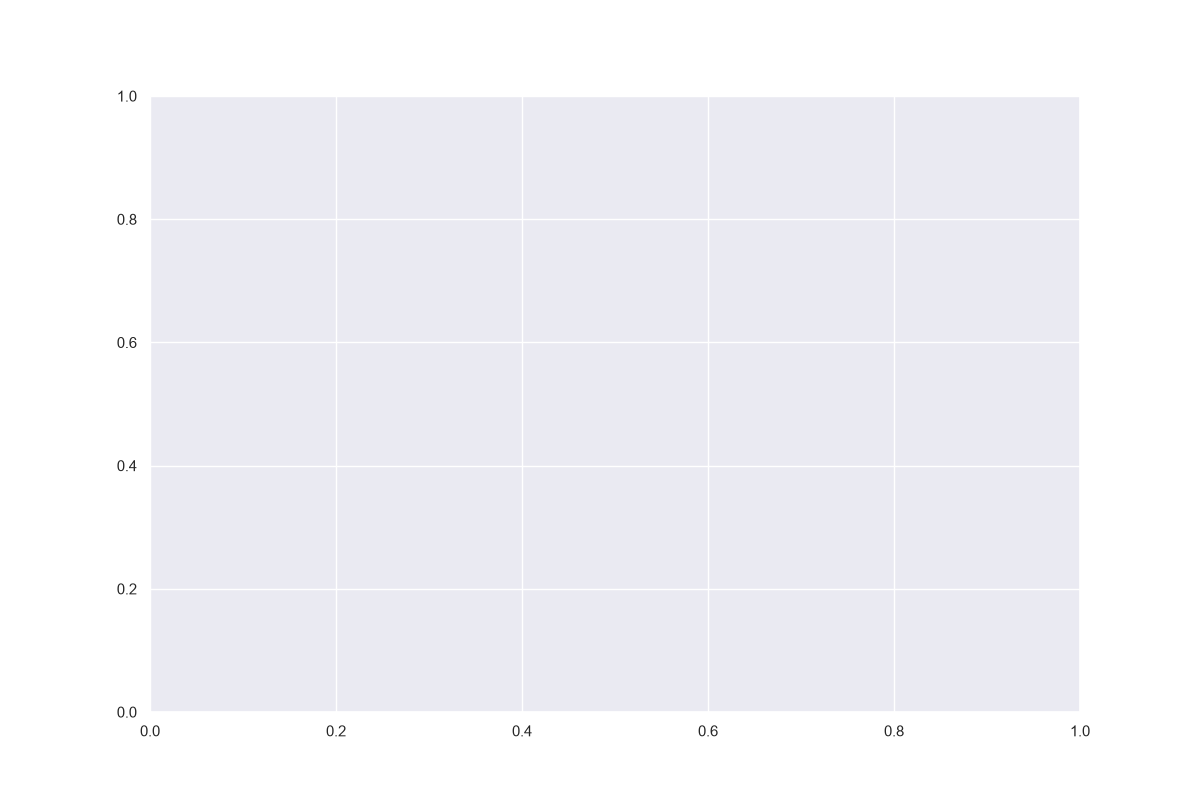

In [97]:
default_year = 2016

fig = plt.figure(figsize=(12,8))

year_slider = widgets.IntSlider(
    value=default_year,
    min=2003,
    max=2025,
    step=1,
    description='Year:',
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d'
)

def plot_lom_transect(change, fig):
    fig.clf()
    ax = fig.add_subplot(1,1,1) 

    year = change['new']
    transect = e_ns_cruise_transects[year]

    fig, ax = plotter.plot_transect(
        transect=transect,
        x = 'distance',
        y = 'depth',
        data = 'CT',
        fig = fig,
        ax = ax,
        cmap = colormaps['seismic'],
        title = f'{year} Thermal Wind (based on level of no motion at 1000m)',
        levels = 0.1,
        bounds = {'top': 0, 'bottom': 1000, 'left': 0, 'right': None}
        )


year_slider.observe(lambda b: plot_lom_transect(b, fig), names='value')

display(year_slider)

#Run callback on startup
plot_lom_transect({'new': default_year}, fig,)

plt.show()


#### From Satelite Derived Surface Geostrophic Current

In [ ]:
default_year = 2016

sns.set_theme()

fig = plt.figure(figsize=(12,8))

year_slider = widgets.IntSlider(
    value=default_year,
    min=2003,
    max=2025,
    step=1,
    description='Year:',
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d'
)

def plot_lom_transect(change, fig):
    fig.clf()
    ax = fig.add_subplot(1,1,1) 

    year = change['new']
    transect = e_ns_cruise_transects[year]

    fig, ax = plotter.plot_transect(
        transect=transect,
        x = 'distance',
        y = 'depth',
        data = 'asv_surf_current',
        fig = fig,
        ax = ax,
        cmap = colormaps['seismic'],
        title = f'{year} Thermal Wind (based on surface geostrophic currents)',
        levels = 0.1,
        bounds = {'top': 0, 'bottom': 1000, 'left': 0, 'right': None}
        )


year_slider.observe(lambda b: plot_lom_transect(b, fig), names='value')

display(year_slider)

#Run callback on startup
plot_lom_transect({'new': default_year}, fig,)

plt.show()

#### Combined Figure

In [ ]:
default_year = 2016

fig = plt.figure(figsize=(18,8))

year_slider = widgets.IntSlider(
    value=default_year,
    min=2003,
    max=2025,
    step=1,
    description='Year:',
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d'
)

def plot_lom_transect(change, fig):
    fig.clf()
    axs = fig.subplots(1,2) 

    year = change['new']
    transect = n_ew_cruise_transects[year]

    ax = axs[0]
    fig, ax = plotter.plot_transect(
        transect=transect,
        x = 'distance',
        y = 'depth',
        data = 'asv_lom_1000',
        fig = fig,
        ax = ax,
        cmap = colormaps['seismic'],
        title = f'Thermal Wind (level of no motion at 1000m)',
        levels = 0.07,
        bounds = {'top': 0, 'bottom': 1000, 'left': 0, 'right': None}
        )

    ax = axs[1]
    fig, ax = plotter.plot_transect(
        transect=transect,
        x = 'distance',
        y = 'depth',
        data = 'asv_surf_current',
        fig = fig,
        ax = ax,
        cmap = colormaps['seismic'],
        title = f'Thermal Wind (surface geostrophic current)',
        levels = 0.07,
        bounds = {'top': 0, 'bottom': 1000, 'left': 0, 'right': None}
        )

    fig.suptitle(str(year))

year_slider.observe(lambda b: plot_lom_transect(b, fig), names='value')

display(year_slider)

#Run callback on startup
plot_lom_transect({'new': default_year}, fig)

plt.show()

### Generate large figure with transects from each year for easy comparison

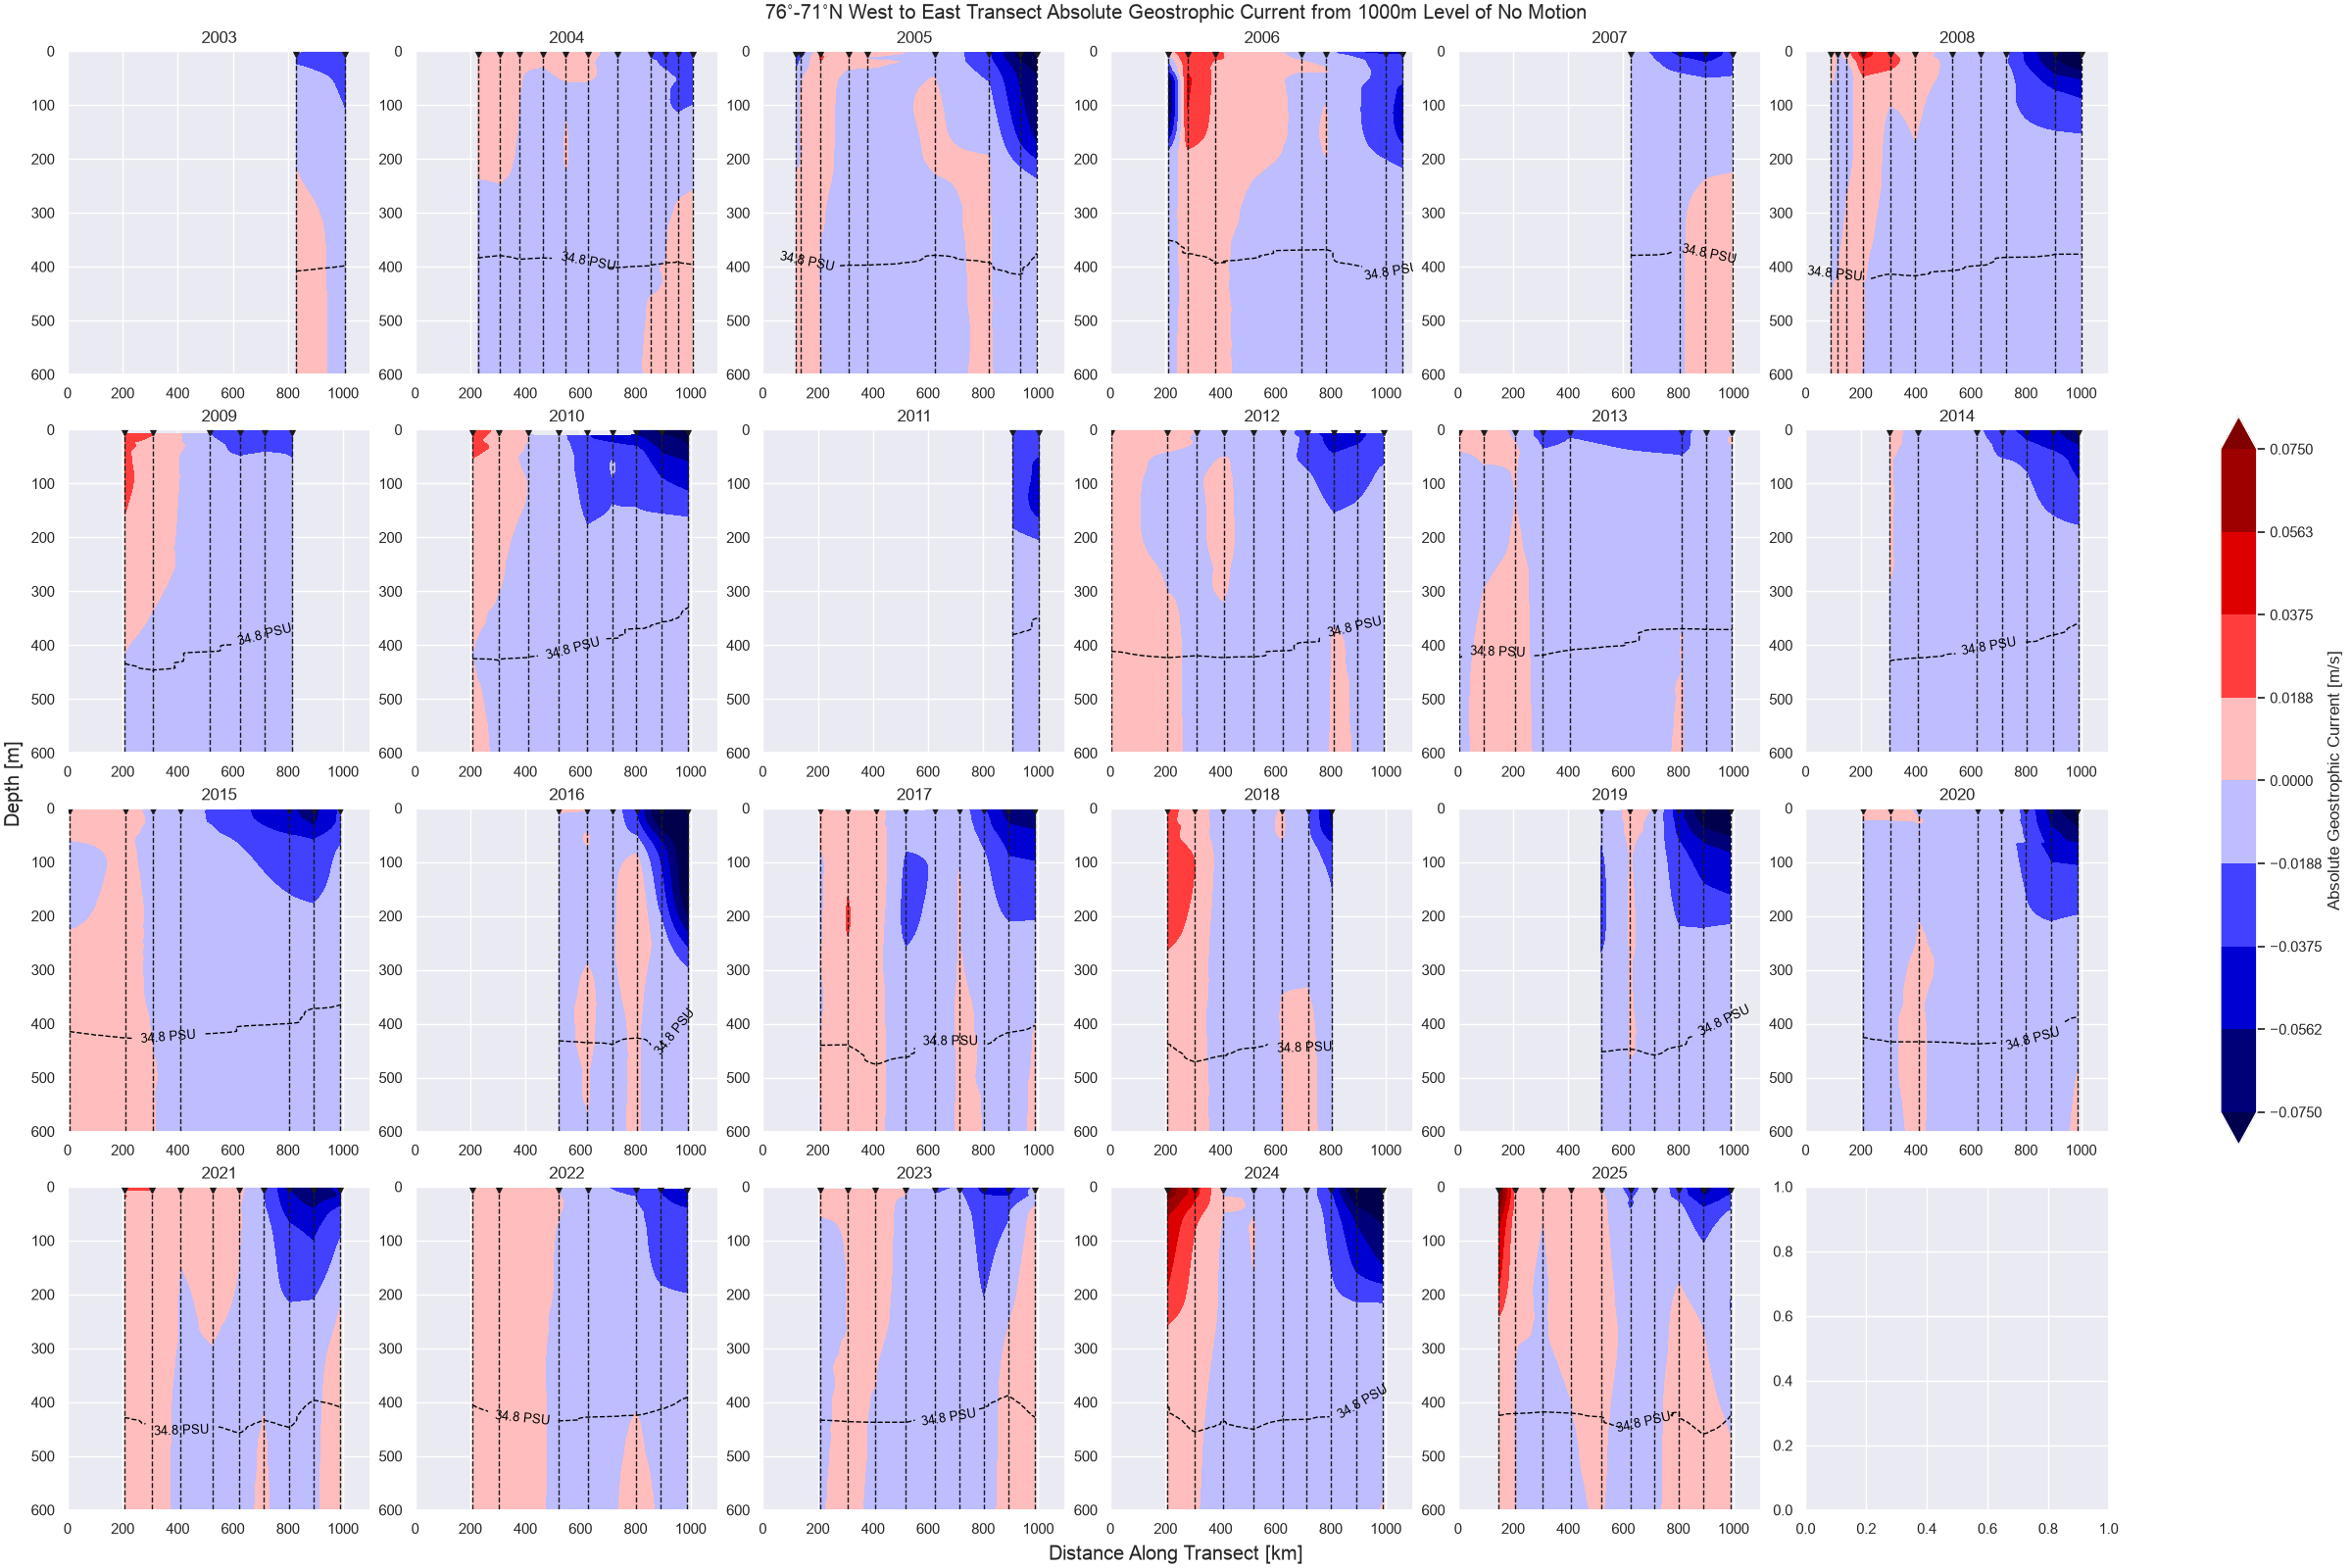

In [167]:
mega_figure = plt.figure(figsize = (24, 16), layout="constrained")

sns.set_theme()

data_sets_dicts = [e_ns_cruise_transects, w_ns_cruise_transects, n_ew_cruise_transects, s_ew_cruise_transects]

track_names = ['140˚W South to North', '150˚W South to North', '78˚-75˚N West to East','76˚-71˚N West to East']
file_names = ['ns_e', 'ns_w', 'ew_n', 'ew_s']
right_limits = [900, 1100, 600, 1100]

variable = 'agv_lnm_1000'

for i, transect_dict in enumerate(data_sets_dicts):
    track_name = track_names[i]
    mega_figure.clf()
    axs = mega_figure.subplots(4,6)
    for j, key in enumerate(transect_dict):
        year = key
        transect = transect_dict[year]

        index = np.unravel_index(j, (4,6))

        mega_figure, axs[index], cbar_obj = plotter.plot_transect(
            transect=transect,
            x = 'distance',
            y = 'depth',
            data = variable,
            fig = mega_figure,
            ax = axs[index],
            cmap = colormaps['seismic'],
            title = str(year),
            levels = 0.075,
            colorbar = False,
            bounds = {'top': 0, 'bottom': 600, 'left': 0, 'right': right_limits[i]},
            xlabel=False,
            ylabel=False,
            legend=False,
            seafloor=False
        )

    mega_figure.suptitle(f"{track_name} Transect Absolute Geostrophic Current from 1000m Level of No Motion")
    mega_figure.supxlabel("Distance Along Transect [km]")
    mega_figure.supylabel("Depth [m]")
    mega_figure.colorbar(cbar_obj, ax = axs, label = "Absolute Geostrophic Current [m/s]", shrink = 0.5)
    file_name = f"{file_names[i]}_{variable}.png"
    plt.savefig(f"/Users/ben/Desktop/3D-TEA-BAG/plots/{file_name}")


#### Depth Averaged Geostrophic Velocity (down to 34.8 PSU contour)

In [125]:
transect = n_ew_cruise_transects[2005]

agv = transect['agv_lnm_1000']